# Building an ML Model for Salary Prediction

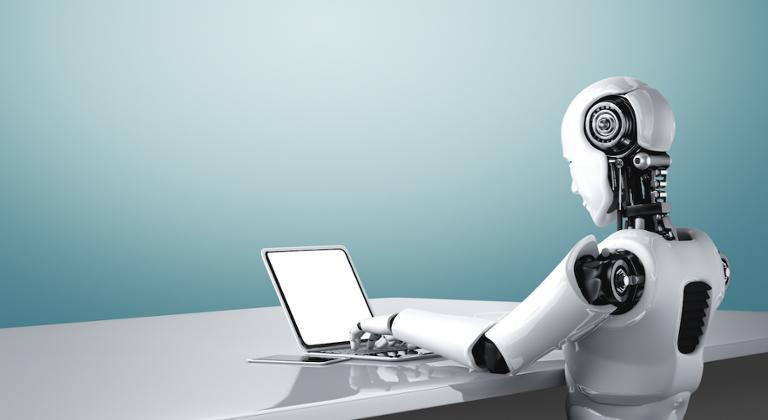

# AI Jobs Salary Prediction Project

This project aims to build a machine learning model that predicts salaries for AI and data-related jobs using a public dataset of job listings. The main target variable is `salary_in_usd`, which standardizes salaries across different currencies and helps create a more reliable prediction model.

## Project Objective
- Explore how salary varies by job role, experience level, work mode, company size, and country.
- Clean and prepare the dataset for modeling.
- Perform exploratory data analysis (EDA) to understand the structure and quality of the data.
- Build and compare regression models to predict salaries.
- Evaluate the models using appropriate performance metrics.

## Steps Taken in the Project

### 1. Data Collection
- Loaded the dataset from a GitHub source using `pandas.read_csv()`.
- Inspected the dataframe structure, columns, and data types.

### 2. Data Cleaning
- Checked for missing values and duplicates.
- Removed irrelevant or redundant columns, such as `isco_group_hint`.
- Verified the dataset quality before modeling.

### 3. Exploratory Data Analysis (EDA)
- Reviewed statistical summaries for numerical variables.
- Analyzed salary distribution, skewness, and outliers.
- Investigated categorical features such as:
    - `company_location`
    - `employee_residence`
    - `employment_type`
    - `experience_level`
    - `work_mode`
    - `company_size`
    - `role_family`
- Identified class imbalance and feature sparsity in several categorical variables.

### 4. Feature Engineering
- Created derived columns such as `salary_category`.
- Mapped categorical codes to more descriptive labels.
- Converted relevant features to a format suitable for modeling.
- Dropped variables that were redundant or not useful for the prediction task.

### 5. Data Preparation for Modeling
- Selected the target variable as `salary_in_usd`.
- Split the dataset into training and testing sets.
- Encoded categorical variables for machine learning compatibility.

### 6. Model Development
- Built baseline regression models such as:
    - Linear Regression
    - Pipeline-based models with scaling
- Evaluated model performance using:
    - R² score
    - RMSE
    - MAE

### 7. Model Evaluation and Comparison
- Assessed model performance on both training and test data.
- Compared different modeling approaches.
- Reviewed correlations and selected important features.

### 8. Interpretation and Insights
- Analyzed which factors are most related to salary.
- Discussed how experience level, role type, remote work, and country affect pay.
- Used visualizations to communicate key patterns and trends in the dataset.

## Outcome
This project demonstrates a complete machine learning workflow for salary prediction in the AI jobs market, covering data exploration, cleaning, feature preparation, model building, and evaluation. The final model provides a useful foundation for understanding compensation trends and predicting salaries for similar job roles.

Python libraries


In [362]:
# Surpress warnings:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import boxcox
from sklearn.preprocessing import Normalizer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

### Set a function

In [363]:
def  plot_dis(y,yhat):
    
    plt.figure()
    ax1 = sns.distplot(y, hist=False, color="r", label="Actual Value")
    sns.distplot(yhat, hist=False, color="b", label="Fitted Values" , ax=ax1)
    plt.legend()

    plt.title('Actual vs Fitted Values')
    plt.xlabel('salary (in dollars)')
    plt.ylabel('Proportion of salary')

    plt.show()
    plt.close()

#### Load the dataset

In [364]:
url = "https://raw.githubusercontent.com/JoshuaKab/Kaggle_project/main/ai_jobs_salaries_clean.csv"

data = pd.read_csv(url, encoding="latin-1")

In [365]:
data.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,experience_level_label,employment_type_label,work_mode,salary_outlier_flag,role_family,isco_group_hint
0,2025,EX,FT,Head of Data,348516,USD,348516,US,0,US,M,Executive-level,Full-time,On-site,True,Analytics Manager,Information and communications technology serv...
1,2025,EX,FT,Head of Data,232344,USD,232344,US,0,US,M,Executive-level,Full-time,On-site,False,Analytics Manager,Information and communications technology serv...
2,2025,SE,FT,Data Scientist,145400,USD,145400,US,0,US,M,Senior-level,Full-time,On-site,False,Data Scientist,"Mathematicians, actuaries and statisticians"
3,2025,SE,FT,Data Scientist,81600,USD,81600,US,0,US,M,Senior-level,Full-time,On-site,False,Data Scientist,"Mathematicians, actuaries and statisticians"
4,2025,MI,FT,Engineer,160000,USD,160000,US,100,US,M,Mid-level,Full-time,Remote,False,Other / Unclassified,NaN


## **Data Cleaning and Wrangling**

Here, we'll check if there's missing value, duplicates, etc...

In [366]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 71913 entries, 0 to 71912
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   work_year               71913 non-null  int64
 1   experience_level        71913 non-null  str  
 2   employment_type         71913 non-null  str  
 3   job_title               71913 non-null  str  
 4   salary                  71913 non-null  int64
 5   salary_currency         71913 non-null  str  
 6   salary_in_usd           71913 non-null  int64
 7   employee_residence      71913 non-null  str  
 8   remote_ratio            71913 non-null  int64
 9   company_location        71913 non-null  str  
 10  company_size            71913 non-null  str  
 11  experience_level_label  71913 non-null  str  
 12  employment_type_label   71913 non-null  str  
 13  work_mode               71913 non-null  str  
 14  salary_outlier_flag     71913 non-null  bool 
 15  role_family             71913 

In [367]:
data.isna().sum()

work_year                     0
experience_level              0
employment_type               0
job_title                     0
salary                        0
salary_currency               0
salary_in_usd                 0
employee_residence            0
remote_ratio                  0
company_location              0
company_size                  0
experience_level_label        0
employment_type_label         0
work_mode                     0
salary_outlier_flag           0
role_family                   0
isco_group_hint           40540
dtype: int64

### Delete isco_group_hint column

The dataset doen not have Null values after deleting isco_group_int column

In [368]:
data.drop(['isco_group_hint'], axis=1, inplace=True)

In [369]:
data.columns.tolist()

['work_year',
 'experience_level',
 'employment_type',
 'job_title',
 'salary',
 'salary_currency',
 'salary_in_usd',
 'employee_residence',
 'remote_ratio',
 'company_location',
 'company_size',
 'experience_level_label',
 'employment_type_label',
 'work_mode',
 'salary_outlier_flag',
 'role_family']

In [370]:
#check for duplicate
data.duplicated().sum()

np.int64(0)

There is no duplicates and no missing value

Well the data has been well structure now we can do some more check

In [371]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
work_year,71913.0,2024.425153,0.721198,2020.0,2024.0,2025.0,2025.0,2025.0
salary,71913.0,161710.163823,287286.815546,14000.0,96400.0,139700.0,192200.0,30400000.0
salary_in_usd,71913.0,151161.252625,77329.594122,15000.0,96000.0,138750.0,190315.0,800000.0
remote_ratio,71913.0,24.569271,42.917779,0.0,0.0,0.0,0.0,100.0


The are 4 numerical feature column but there's actually two column of salary. let's some inspection

In [372]:
for col in data.columns:
    print(f"\n{col}")
    print(data[col].nunique())


work_year
6

experience_level
4

employment_type
4

job_title
422

salary
12308

salary_currency
26

salary_in_usd
13580

employee_residence
104

remote_ratio
3

company_location
97

company_size
3

experience_level_label
4

employment_type_label
4

work_mode
3

salary_outlier_flag
2

role_family
11


Let's check the categorical feature columns

In [373]:
categorical_cols = data.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n===== {col} =====")
    print(data[col].value_counts(dropna=False).head(20))


===== experience_level =====
experience_level
SE    37702
MI    23395
EN     7975
EX     2841
Name: count, dtype: int64

===== employment_type =====
employment_type
FT    71163
CT      383
PT      351
FL       16
Name: count, dtype: int64

===== job_title =====
job_title
Data Scientist               7160
Data Engineer                7071
Data Analyst                 6405
Software Engineer            4921
Engineer                     4375
Manager                      3612
Machine Learning Engineer    3462
Analyst                      2783
Research Scientist           1381
Analytics Engineer           1341
Product Manager              1326
Associate                    1238
Data Architect               1231
AI Engineer                  1163
Research Engineer             887
Consultant                    783
Developer                     715
Data Manager                  697
Data Specialist               669
Systems Engineer              563
Name: count, dtype: int64

===== salary_currenc

### What stands out
The dataset is heavily US-centric.
employee_residence and company_location are dominated by the US (~60k of ~72k records). Country-level comparisons will therefore be highly imbalanced.

Company size is extremely imbalanced.

* M: 70,110
* L: 1,588
* S: 215

A model can easily learn that almost everything is "M", so we'll need to treat this carefully.

Employment type is almost entirely full-time.

* FT: 71,163
* CT: 383
* PT: 351
* FL: 16

We should probably not make employment type a major analytical question, because the minority groups are very small.

Work mode is also highly imbalanced.

* On-site: 54,081
* Remote: 17,505
* Hybrid: 327

Hybrid is particularly sparse.

experience_level and experience_level_label are duplicates conceptually.
For example:
> SE → Senior-level, MI → Mid-level, etc. We should retain one representation for modeling, not both.
role_family is potentially much more useful than raw job_title.

> You have thousands of job-title variations, while role_family gives us a manageable set of categories. However, "Other / Unclassified" contains ~40,540 records, so we need to investigate how that category was generated.

> Currency is overwhelmingly USD.
This is actually helpful for salary modeling because you already have salary_in_usd. For salary prediction, I would use salary_in_usd as the target and generally exclude the original salary and salary_currency.

More details on the Dataframe detils

In [374]:
print("Check the dataset size and numerical variables")

print("Number Rows:", len(data))
print("Number Columns:", len(data.columns))

print("\nNumerical columns:")
print(data.select_dtypes(include="number").columns.tolist())

print("\nCategorical columns:")
print(data.select_dtypes(include="object").columns.tolist())

Check the dataset size and numerical variables
Number Rows: 71913
Number Columns: 16

Numerical columns:
['work_year', 'salary', 'salary_in_usd', 'remote_ratio']

Categorical columns:
['experience_level', 'employment_type', 'job_title', 'salary_currency', 'employee_residence', 'company_location', 'company_size', 'experience_level_label', 'employment_type_label', 'work_mode', 'role_family']


Let count the number of jobs per job title 

In [375]:
other_roles = (
    data.loc[
        data["role_family"] == "Other / Unclassified",
        "job_title"
    ]
    .value_counts()
)

print(other_roles.head(50))

job_title
Software Engineer                4921
Engineer                         4375
Manager                          3612
Analyst                          2783
Analytics Engineer               1341
Product Manager                  1326
Associate                        1238
Data Architect                   1231
Consultant                        783
Developer                         715
Data Manager                      697
Data Specialist                   669
Systems Engineer                  563
Architect                         543
Engineering Manager               524
Software Developer                523
Director                          512
Solutions Architect               436
Platform Engineer                 411
Software Development Engineer     409
DevOps Engineer                   382
Machine Learning Scientist        359
Business Analyst                  350
Site Reliability Engineer         333
Research Analyst                  321
Data Governance                   294
So

Software engineer and Engineer job title are the most dominant in this project

### Now let's check the parcentge contaent per column

In [376]:
for col in data.describe(include='object').columns:
    #print(col)
    print(data[col].value_counts(normalize=True)*100)
    print('-'*30)

experience_level
SE    52.427238
MI    32.532365
EN    11.089789
EX     3.950607
Name: proportion, dtype: float64
------------------------------
employment_type
FT    98.957073
CT     0.532588
PT     0.488090
FL     0.022249
Name: proportion, dtype: float64
------------------------------
job_title
Data Scientist              9.956475
Data Engineer               9.832715
Data Analyst                8.906595
Software Engineer           6.842991
Engineer                    6.083740
                              ...   
Deep Learning Researcher    0.001391
Marketing Data Engineer     0.001391
Data Science Tech Lead      0.001391
Principal Data Architect    0.001391
Cloud Data Architect        0.001391
Name: proportion, Length: 422, dtype: float64
------------------------------
salary_currency
USD    91.652413
GBP     3.780958
EUR     3.153811
CAD     0.792624
INR     0.190508
PLN     0.127932
CHF     0.059794
AUD     0.045889
PHP     0.040327
BRL     0.027811
SGD     0.023640
JPY     0.0180

### Check salary quality

This is particularly important because salary will be our target.

In [377]:
print(data[["salary_in_usd", 'salary']].describe(
    percentiles=[
        .01, .05, .10, .25,
        .50,
        .75, .90, .95, .99
    ]
))

       salary_in_usd        salary
count   71913.000000  7.191300e+04
mean   151161.252625  1.617102e+05
std     77329.594122  2.872868e+05
min     15000.000000  1.400000e+04
1%      31988.560000  3.120000e+04
5%      53718.600000  5.107980e+04
10%     67500.000000  6.660000e+04
25%     96000.000000  9.640000e+04
50%    138750.000000  1.397000e+05
75%    190315.000000  1.922000e+05
90%    250000.000000  2.507616e+05
95%    290000.000000  2.950000e+05
99%    391000.000000  4.200000e+05
max    800000.000000  3.040000e+07


This output is a **descriptive statistical summary** 
 ### 1\. Count

```
count = 71,913
```

 There are **71,913 salary records** in both columns.

 So, assuming these are the same rows, neither column has missing values for these observations.

---

 ### 2\. Mean — average salary

```
salary_in_usd: 151,161
salary:        161,710
```

 The average salary is about:

 - **$151,161** for `salary_in_usd`
- **161,710** in the original `salary` column

 The important thing here is that the mean can be strongly affected by **very high salaries**.

---

 ### 3\. Standard deviation

```
salary_in_usd: 77,330
salary:       287,287
```

 Standard deviation measures how spread out the salaries are around the mean.

 The original `salary` column has a **much larger standard deviation** because of some extremely large salary values.

 This becomes obvious when looking at the maximum:

```
salary_in_usd max = 800,000
salary max        = 30,400,000
```

 That **30.4 million** value is dramatically larger than the rest of the salaries.

---

 ### 4. Minimum

```
salary_in_usd = 15,000
salary        = 14,000
```

 The lowest recorded salaries are approximately $15,000 and 14,000 respectively.


 ### 5\. Mean vs median

 This is one of the most important things to notice.

```
Mean   = $151,161
Median = $138,750
```

 The mean is higher than the median.

 That suggests the distribution is **right-skewed**: there are relatively high salaries pulling the average upward.

 For salary data, the **median is often more representative of a typical employee's salary** than the mean.


```
99th percentile = 420,000
Maximum         = 30,400,000
```

 That's a huge difference.

 It strongly suggests that the original `salary` column contains **extreme outliers**.

 Notice how:

```
salary mean = 161,710
salary median = 139,700
salary max = 30,400,000
```

 That $30.4 million observation has a substantial effect on the mean and standard deviation.

 So if you're doing **EDA (Exploratory Data Analysis)**, `salary_in_usd` is likely the more useful column for comparing salary levels.

 ### In simple terms

data discribed:

 > **A typical salary is around $139k (median), while the average is around $151k. Most salaries fall between roughly $96k and $190k, but there are some high-salary observations that pull the distribution upward. The original `salary` column contains an extreme $30.4M value that is likely an outlier.**

 

This output is a descriptive statistical summary of the two columns salary_in_usd and salary. It tells you how salaries are distributed in your dataset

In [378]:
print(data["salary_outlier_flag"].value_counts(dropna=False))

salary_outlier_flag
False    70159
True      1754
Name: count, dtype: int64


In [379]:
pd.crosstab(
    data["salary_outlier_flag"],
    data["experience_level_label"],
    normalize="index"
)

experience_level_label,Entry-level,Executive-level,Mid-level,Senior-level
salary_outlier_flag,,,,
False,0.112986,0.037600,0.327413,0.522000
True,0.027366,0.115735,0.241733,0.615165


### country variables need careful treatment

You have:

`employee_residence`
`company_location`

These are potentially powerful predictors.

But the distribution is heavily dominated by the US.

Therefore, don't immediately make an analysis like:

"Which country pays the highest salary?"

because countries with tiny sample sizes can produce misleading averages.

Instead, establish a minimum sample threshold.

In [380]:
country_counts = data["company_location"].value_counts()

valid_countries = country_counts[
    country_counts >= 100
].index

country_salary = (
    data[data["company_location"].isin(valid_countries)]
    .groupby("company_location")["salary_in_usd"]
    .agg(["count", "mean", "median"])
    .sort_values("median", ascending=False)
)

country_salary

,count,mean,median
company_location,,,
US,60147,160275.470165,147200.0
CA,4571,130319.582148,119875.0
AU,511,126349.086106,117000.0
IE,125,109692.248000,97473.0
DE,400,101561.730000,85000.0
GB,2835,98752.944621,76202.0
PL,147,76628.639456,74000.0
NL,398,80526.743719,72265.0
FR,302,71849.456954,58113.5


In [381]:
pd.crosstab(
    data["remote_ratio"],
    data["work_mode"],
    normalize="index"
)

work_mode,Hybrid,On-site,Remote
remote_ratio,,,
0,0.0,1.0,0.0
50,1.0,0.0,0.0
100,0.0,0.0,1.0


### EXPLORATORY DATA ANALYSIS(EDA

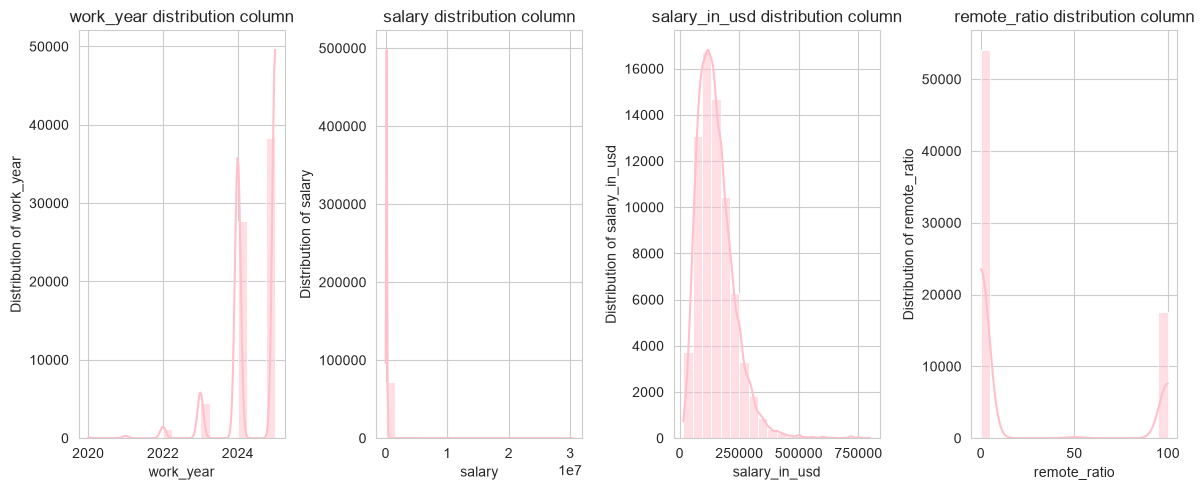

In [382]:
#Data exploratory analys
numerical_features = data.select_dtypes(include='number').columns.tolist()  # Example to get numberic features

sns.set_style("whitegrid")

plt.figure(figsize=(12, 5))

# Loop through numerical features
for i, column in enumerate(numerical_features, start=1):  # Use enumerate to get the index
    plt.subplot(1, 4, i)  # Adjust the number of rows and columns as needed
    sns.histplot(data[column], bins=20, kde=True, color='pink')
    plt.title(f'{column} distribution column')
    plt.xlabel(column)
    plt.ylabel(f'Distribution of {column}')

plt.tight_layout()
plt.show()

## Distribution of important numerical variables

 ### 1\. `work_year` distribution

 The first graph shows the number of records/jobs for each year.

 - There are relatively few records in the earlier years, around **2020–2022**.
- The number of records increases significantly in **2023 and 2024**.
- **2025 appears to have the highest number of records**.
- This means your dataset contains substantially more observations from the most recent years.

 **Interpretation:**

 > The dataset is concentrated in the later years, particularly 2023–2025. Therefore, analysis of salary or employment trends may be more representative of recent years than earlier years.


 ### 2\. `salary` distribution

 The second graph shows the distribution of the original `salary` variable.

 There is a **very large concentration near the lower end**, while the x-axis extends to around **30 million**.

 This suggests:

 - Most salary values are relatively small compared with the maximum.
- There are some **extremely large salary values**.
- These extreme values create a **strong right-skewed distribution**.
- The large values may be **outliers**, or the `salary` variable may use different currencies.

 The graph is therefore difficult to interpret directly.

 **Important:** Your `salary` column should not be confused with `salary_in_usd`. The latter has already been converted to a common currency and is much easier to analyze.


 From the graph:

 - A large proportion of salaries appear to be between approximately **$50,000 and $200,000**.
- The highest concentration appears around roughly **$100,000–$150,000**.
- There are fewer observations as salary increases.
- A small number of salaries extend beyond **$500,000**, with some approaching **$750,000**.
- Therefore, the distribution has a **long right tail**.

 **Interpretation:**

 > Most jobs have salaries in the lower-to-middle range, while a relatively small number of jobs have exceptionally high salaries. This causes the salary distribution to be positively/right skewed.

 This is one reason why using the **median salary** can sometimes be more informative than the mean.



## Looking for Correlations

Let's check how the data are correlated

In [383]:
df_corr = data.select_dtypes(include = ['float64', 'int64'])
df_num_corr = df_corr.corr()['salary_in_usd'] # -1 means that the latest row is price
top_features = df_num_corr[abs(df_num_corr) > 0.1].sort_values(ascending=False) #displays pearsons correlation coefficient 
print("There is {} strongly correlated values with price:\n{}".format(len(top_features), top_features))

There is 2 strongly correlated values with price:
salary_in_usd    1.000000
salary           0.224115
Name: salary_in_usd, dtype: float64


## Data Transformation

In [384]:
# Create salary categories based on salary ranges
data['salary_category'] = data['salary_in_usd'].apply(
    lambda x: "Low" if x < 60000
    else "Mid_Range" if x < 120000
    else "High"
)


# Map experience level codes to descriptive labels
experience_mapping = {
    'EN': 'Entry-level',
    'MI': 'Mid-level',
    'SE': 'Senior-level',
    'EX': 'Executive-level'
}


# Map remote ratio to work mode
remote_mapping = {
    0: 'On-site',
    50: 'Hybrid',
    100: 'Remote'
}


# Map company size codes to descriptive labels
company_mapping = {
    'S': 'Small company',
    'M': 'Medium-sized company',
    'L': 'Large company'
}


# Map employment type codes to descriptive labels
employment_mapping = {
    'FT': 'Full-time',
    'PT': 'Part-time',
    'CT': 'Contract',
    'FL': 'Freelance'
}


# Apply the mappings to the DataFrame
data['experience_level'] = data['experience_level'].map(experience_mapping)
data['remote_ratio'] = data['remote_ratio'].map(remote_mapping)
data['employment_type'] = data['employment_type'].map(employment_mapping)
data['company_size'] = data['company_size'].map(company_mapping)


# Plot work mode distribution
# data['remote_ratio'].value_counts().plot.bar(
#     color=['lightblue', 'red', 'blue']
# )


Barplot the Visualization comparing Salary in usd vs defferent features columns

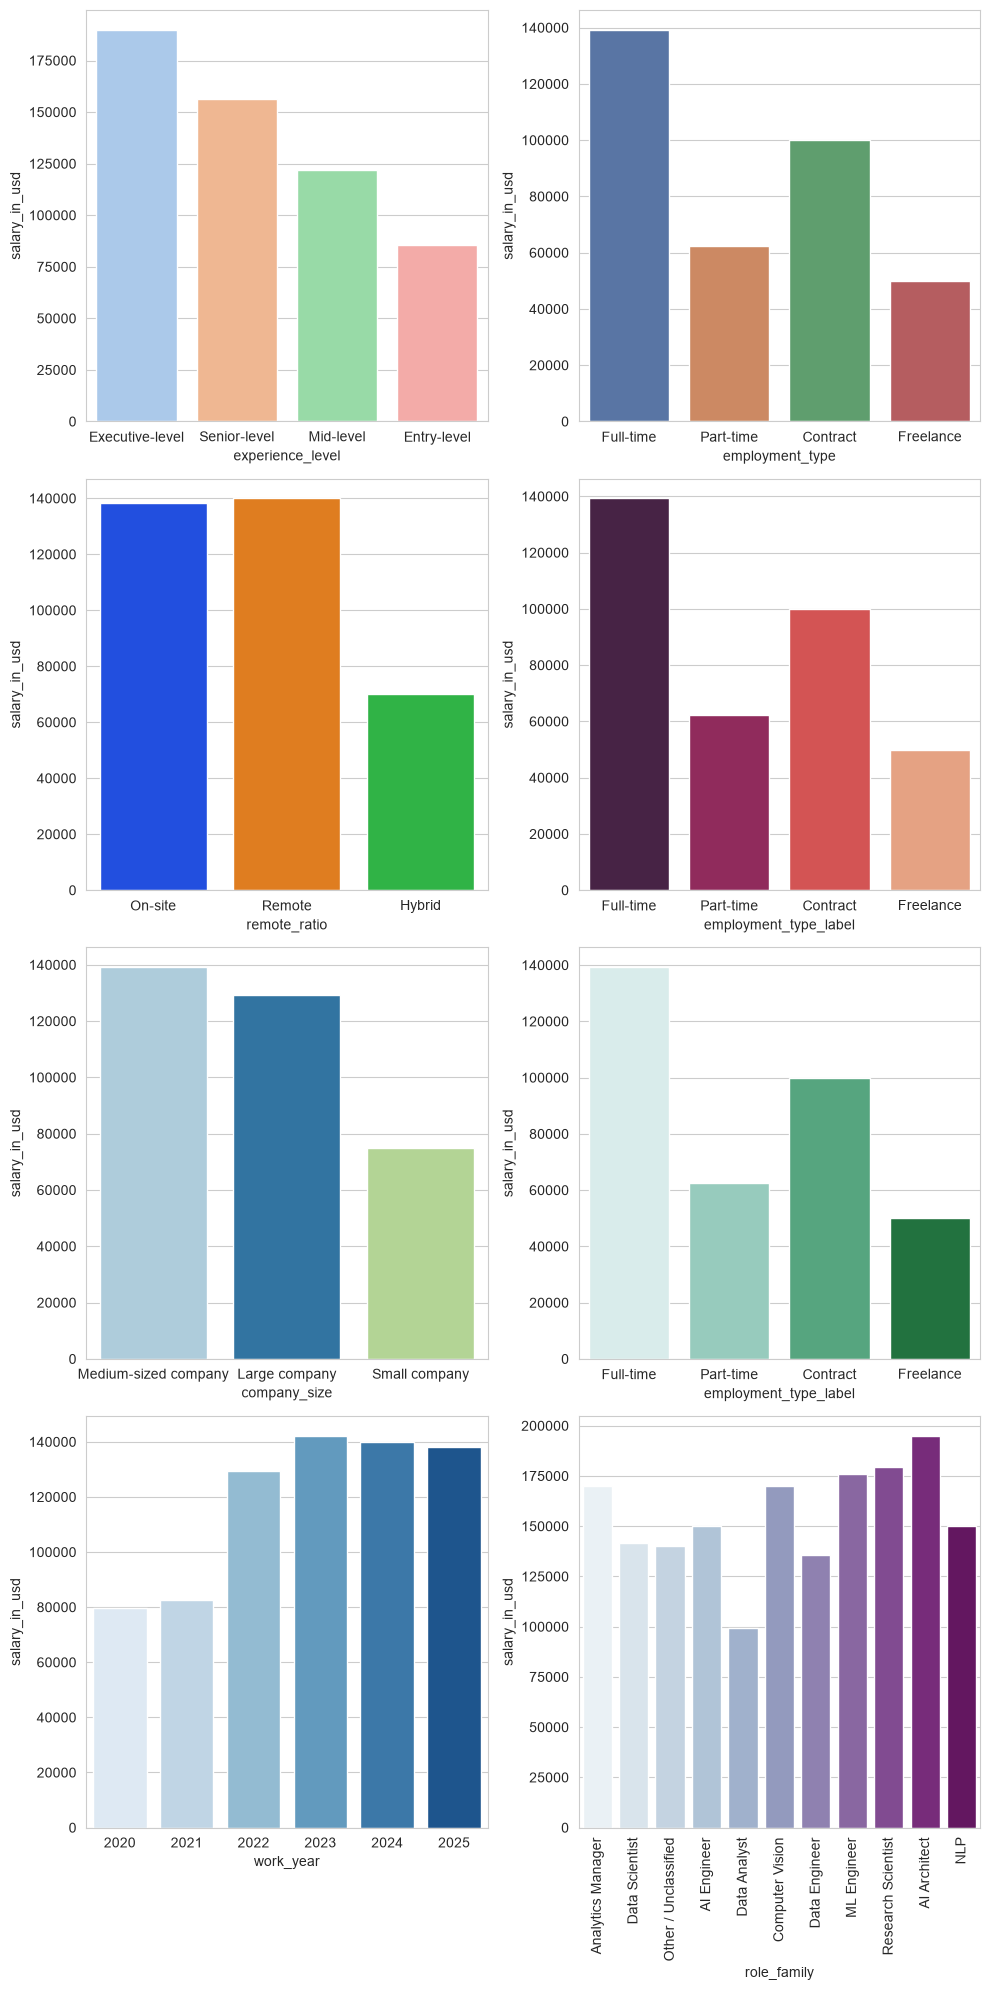

In [385]:
plt.figure(figsize=(10, 20))
plt.subplot(4,2,1)
sns.barplot(x = 'experience_level', y = 'salary_in_usd', palette="pastel", data = data, estimator="median", errorbar=None)
plt.subplot(4,2,2)
sns.barplot(x = 'employment_type', y = 'salary_in_usd', palette="deep", data = data, estimator="median", errorbar=None)
plt.subplot(4,2,3)
sns.barplot(x = 'remote_ratio', y = 'salary_in_usd', palette="bright", data = data, estimator="median", errorbar=None)
plt.subplot(4,2,4)
sns.barplot(x = 'employment_type_label', y = 'salary_in_usd', palette="rocket", data = data, estimator="median", errorbar=None)
plt.subplot(4,2,5)
sns.barplot(x = 'company_size', y = 'salary_in_usd', palette="Paired", data = data, estimator="median", errorbar=None)
plt.subplot(4,2,6)
sns.barplot(x = 'employment_type_label', y = 'salary_in_usd', palette="BuGn", data = data, estimator="median", errorbar=None)
plt.subplot(4,2,7)
sns.barplot(x = 'work_year', y = 'salary_in_usd', palette="Blues", data = data, estimator="median", errorbar=None)
plt.subplot(4,2,8)
sns.barplot(x = 'role_family', y = 'salary_in_usd', palette="BuPu", data = data, estimator="median", errorbar=None)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

There are some typos in the names of the cars, so they should be corrected.


In [386]:
# Group by brand and transmission, and calculate count, mean, and sum of prices
model = data.groupby(["role_family", "remote_ratio"])["salary_in_usd"].agg(['count', 'mean', 'sum']).reset_index()

# Create a DataFrame from the model and apply a background gradient style
model_price = pd.DataFrame(model)
model_price


,role_family,remote_ratio,count,mean,sum
0,AI Architect,On-site,161,220463.453416,35494616
1,AI Architect,Remote,58,188763.258621,10948269
2,AI Engineer,Hybrid,7,93850.000000,656950
3,AI Engineer,On-site,893,167794.689810,149840658
4,AI Engineer,Remote,309,154009.676375,47588990
5,Analytics Manager,Hybrid,4,119144.000000,476576
6,Analytics Manager,On-site,353,186283.308782,65758008
7,Analytics Manager,Remote,138,184478.413043,25458021
8,Computer Vision,Hybrid,2,23841.000000,47682
9,Computer Vision,On-site,106,181792.207547,19269974


Average price on the brand categories

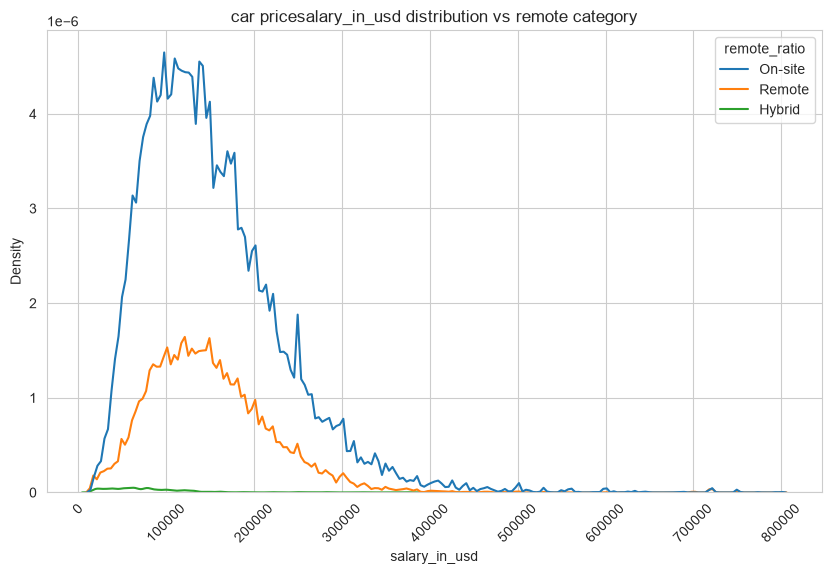

In [387]:
#trand on car brand vs sale price  
plt.figure(figsize=(10,6))
sns.kdeplot(data=data, x = 'salary_in_usd', hue="remote_ratio", bw_adjust=.2)
plt.xticks(rotation=45)
plt.title('car pricesalary_in_usd distribution vs remote category')
plt.show()

INSIGHT

Price compare with mileage column plus  the engine size and transmission, which we find out that automatic and Semi auto, are the most expensives vehicles yet with the loweest mileage.

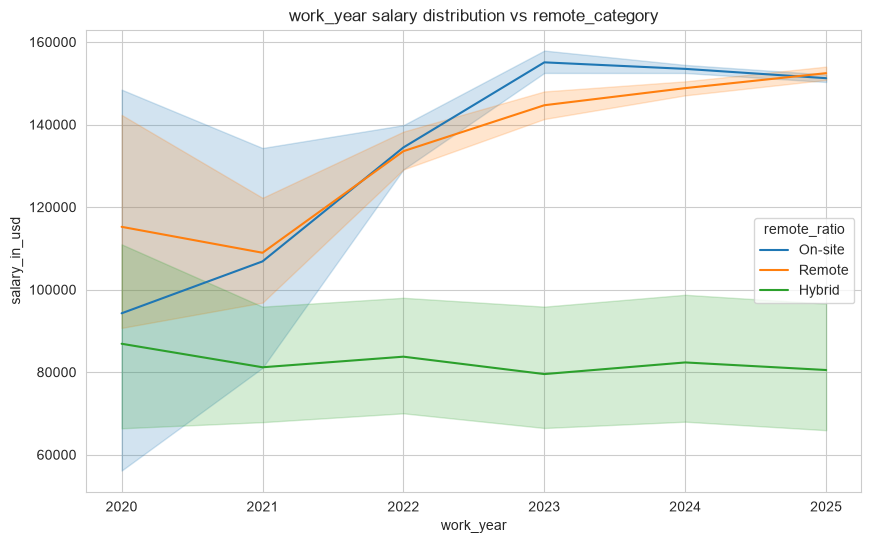

In [388]:
plt.figure(figsize=(10,6))
sns.lineplot(data, x='work_year', y='salary_in_usd', hue='remote_ratio')
plt.title('work_year salary distribution vs remote_category')
plt.show()

INSIGHT

* 2001 is the year when car prices were abnormally decreased, but just after 2003, car prices started to regain their position in the market. With this in mind, since 2005, the hybrid fuel type has been rapidly increasing due to the popular demand, but diesel is still on top of the ranks

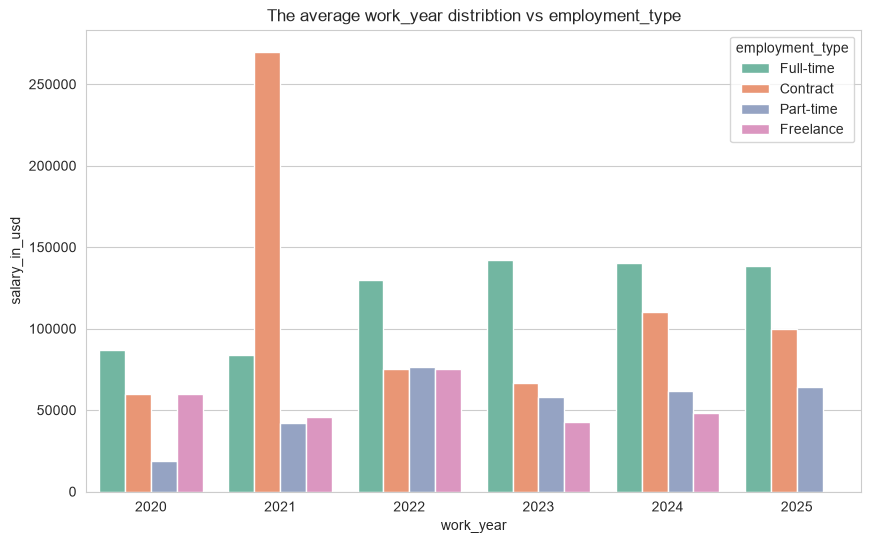

In [389]:
plt.figure(figsize=(10,6))
sns.barplot(data, x='work_year', y='salary_in_usd', hue='employment_type', palette='Set2', estimator="median", errorbar=None)
plt.title('The average work_year distribtion vs employment_type')
plt.show()

## wordCloud 



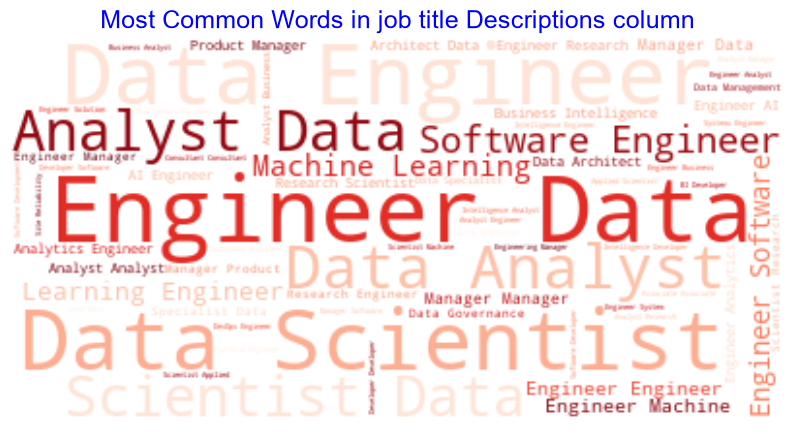

In [390]:
from wordcloud import WordCloud

Job_titles = data['job_title'].values

text = ' '.join(Job_titles)

wordcloud = WordCloud(background_color='white', colormap='Reds', max_words = 200).generate(text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in job title Descriptions column', color='blue', size=18)
plt.show();


These give an idea of other skills, functions, and job categories represented in the dataset.

A simple interpretation for your EDA report
You could write:

"The word cloud shows that data-related terminology dominates the job titles in the dataset. Words such as  `Data Scientist`, `Data`, `Engineer`, `Analyst`, and `Machine Learning` appear frequently, indicating that data science, data engineering, analytics, and software engineering are major job categories represented in the dataset."



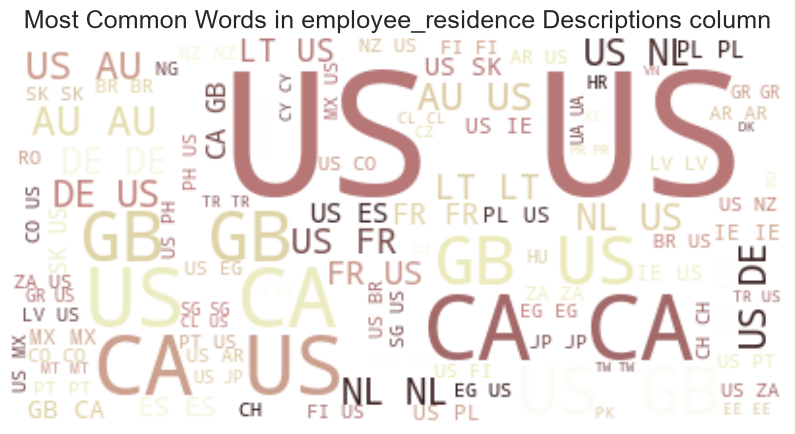

In [391]:
from wordcloud import WordCloud

emp_residence = data['employee_residence'].values

text = ' '.join(emp_residence)

wordcloud = WordCloud(background_color='white', colormap='pink', max_words = 100).generate(text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in employee_residence Descriptions column', size=18)
plt.show();

In [392]:
data.columns.tolist()

['work_year',
 'experience_level',
 'employment_type',
 'job_title',
 'salary',
 'salary_currency',
 'salary_in_usd',
 'employee_residence',
 'remote_ratio',
 'company_location',
 'company_size',
 'experience_level_label',
 'employment_type_label',
 'work_mode',
 'salary_outlier_flag',
 'role_family',
 'salary_category']

I will remove the salary related feature since also higly correlate with the salaty in us

In [393]:
#data.drop(['salary','salary_category'],axis=1, inplace=True)

## Machine Learning Model
In this project our target feature is Salary in usd, 

## Feature engineer 
We'll convert the categorical feature to numerical for machine learning training 

In [394]:
#select features for machine learning
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

categorical_features = data.select_dtypes(exclude=np.number)

Le = LabelEncoder()

for column in categorical_features:
    data[column] = Le.fit_transform(data[column].astype(str))

## Train_test_split DataFrame 

In [395]:
X = data.drop("salary_in_usd", axis=1)
y = data["salary_in_usd"]



# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# Fit preprocessing ONLY on training data
#X_train = preprocessor.fit_transform(X_train)

# Transform test data
#X_test = preprocessor.transform(X_test)



### Correlation matrix

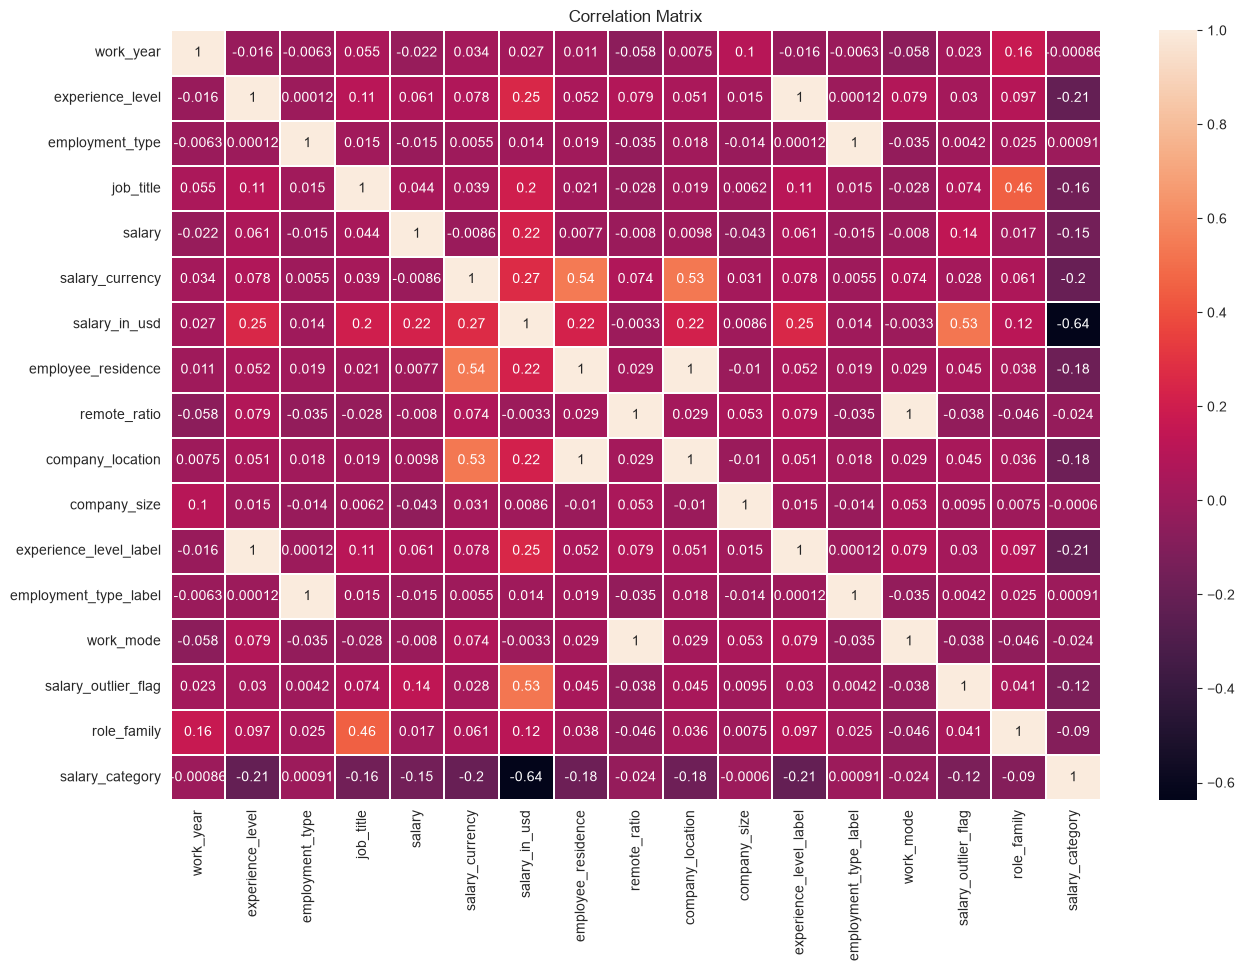

In [396]:
#Plot correlation matrix
plt.figure(figsize=(15,10))
df= data.corr()
sns.heatmap(df, annot=True, linewidth=0.02)
plt.title("Correlation Matrix")
plt.show()

## 1. LinearRegression

In [397]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np


# Create an instance of the LinearRegression model
lr = LinearRegression()

# Fit the model on the training data
lr.fit(X_train, y_train)
    
# Predict on the test data
y_pred = lr.predict(X_test)



Calculate the coefficients from the linear regression model

In [398]:
# Assuming lr is your fitted linear regression model and X is your feature DataFrame
coef = lr.coef_  # Get the coefficients from the linear regression model
column = X.columns  # Get the feature names

# Create a DataFrame with feature names and their corresponding coefficients
df_ = pd.DataFrame({'Feature': column, 'Coefficient': coef})

# Reset the index if needed (not necessary here since we are creating a new DataFrame)
df_ = df_.reset_index(drop=True).sort_values(by='Coefficient')

# Display the DataFrame
print(df_)

                   Feature   Coefficient
15         salary_category -45988.630422
12               work_mode  -2526.052887
7             remote_ratio  -2526.052887
8         company_location   -302.081522
4                   salary      0.040641
11   employment_type_label     22.400666
2          employment_type     22.400666
9             company_size     31.454552
14             role_family     37.303233
3                job_title     59.147817
6       employee_residence    419.966600
13     salary_outlier_flag    748.980574
0                work_year   1843.767784
5          salary_currency   1945.713783
10  experience_level_label   4113.404466
1         experience_level   4113.404466


We apply `predict(`) function on the testing data set.

Let's calculate the `r2_score()` on both, training and testing data sets.

In [399]:
print("R^2 on training  data ",lr.score(X_train, y_train))
print("R^2 on testing data ",lr.score(X_test,y_test))

R^2 on training  data  0.4697936871232543
R^2 on testing data  0.46113860075789925


# Pipeline

We can also use the pipeline to run operations on our data. For example we can standardize our data then perform linear regression by applying the method <code>fit</code>.

In [400]:
pipe = Pipeline([('ss',StandardScaler() ),('lr', LinearRegression())])
pipe.fit(X_train,y_train)
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('ss', ...), ('lr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['work_year','experience_level','employment_type',..., 'salary_outlier_flag','role_family','salary_category']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [401]:
pipe.score(X_train,y_train)

0.6554372240464587

Using the training data only, the R squared is \~ 0.77.\
Now, let's check the R squared on the test set.

In [402]:
pipe.score(X_test,y_test)

0.6556619946391185

The R squared is 0.77. This value provides more accurate evaluation of our model since we test our model on the 'unseen' data set. visit this [documentation](https://en.wikipedia.org/wiki/Overfitting?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML240ENSkillsNetwork34171862-2022-01-01) on overfitting.




In [403]:
# Enter your code and run the cell
pipe_1 = Pipeline([('nn',Normalizer() ),('lr', LinearRegression())])
pipe_1.fit(X_train, y_train)

pipe_1.score(X_train,y_train)
pipe_1.score(X_test,y_test)

pred =pipe_1.predict(X_test)

mse = mean_squared_error(y_true=y_test, y_pred=pred)
rmse = np.sqrt(mse)
rmse

np.float64(35179.632903853424)

We can use the test data to select a feature with the best performance. We have a list of features:


In [404]:
features=list(X)
features

['work_year',
 'experience_level',
 'employment_type',
 'job_title',
 'salary',
 'salary_currency',
 'employee_residence',
 'remote_ratio',
 'company_location',
 'company_size',
 'experience_level_label',
 'employment_type_label',
 'work_mode',
 'salary_outlier_flag',
 'role_family',
 'salary_category']

In [405]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

R_2_train = []
R_2_test = []

pipe = Pipeline([
    ('ss', StandardScaler()),
    ('lr', LinearRegression())
])

for feature in features:
    # Train using one feature
    pipe.fit(X_train[[feature]], y_train)

    # Training R²
    train_r2 = pipe.score(X_train[[feature]], y_train)
    R_2_train.append(train_r2)

    # Test R²
    test_r2 = pipe.score(X_test[[feature]], y_test)
    R_2_test.append(test_r2)

# Display results
for feature, train_r2, test_r2 in zip(features, R_2_train, R_2_test):
    print(
        f"{feature}: "
        f"Train R² = {train_r2:.4f}, "
        f"Test R² = {test_r2:.4f}"
    )

work_year: Train R² = 0.0007, Test R² = 0.0008
experience_level: Train R² = 0.0620, Test R² = 0.0588
employment_type: Train R² = 0.0001, Test R² = 0.0003
job_title: Train R² = 0.0415, Test R² = 0.0372
salary: Train R² = 0.0592, Test R² = 0.0253
salary_currency: Train R² = 0.0705, Test R² = 0.0730
employee_residence: Train R² = 0.0484, Test R² = 0.0510
remote_ratio: Train R² = 0.0000, Test R² = -0.0000
company_location: Train R² = 0.0472, Test R² = 0.0499
company_size: Train R² = 0.0001, Test R² = 0.0000
experience_level_label: Train R² = 0.0620, Test R² = 0.0588
employment_type_label: Train R² = 0.0001, Test R² = 0.0003
work_mode: Train R² = 0.0000, Test R² = -0.0000
salary_outlier_flag: Train R² = 0.2784, Test R² = 0.2822
role_family: Train R² = 0.0136, Test R² = 0.0131
salary_category: Train R² = 0.4066, Test R² = 0.4071


Now, we select the feature that works best, using `argmax()` function.

In [406]:
best=features[np.argmax(R_2_test)]
best

'salary_category'

So 'engineSize' is the best feature that produce the highest $R^(2)$. We then train the feature that works using all the data

In [407]:
pipe.fit(X[[best]],y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('ss', ...), ('lr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](1,)",['salary_category']
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,1
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


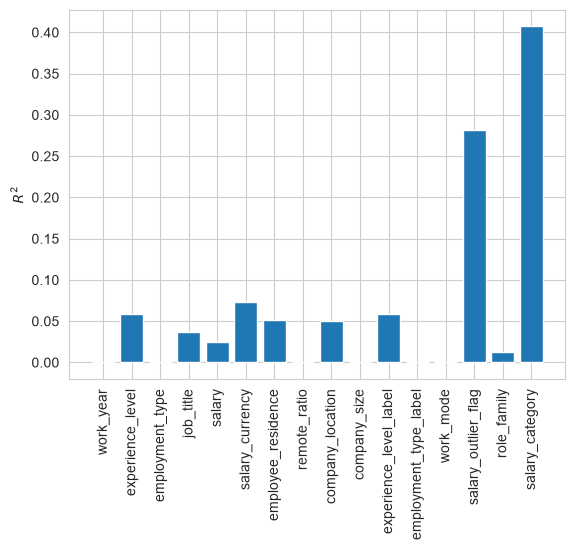

In [408]:
R_2=[]

for feature in features:
      lr.fit(X_train[[feature]], y_train)
      R_2.append(lr.score(X_test[[feature]],y_test))
best=features[np.argmax(R_2)]
plt.bar(features,R_2)
plt.xticks(rotation=90)
plt.ylabel("$R^2$")
plt.show()
best=features[np.argmax(R_2)]

## Cross Validation Score

Now, let's use *Scikit-Learn's* *K-fold cross-validation* method to see whether we can assess the performance of our model. The *K-fold cross-validation* method splits the training set into the number of folds (n_splits), as now in the Diagram above, if we have K folds, K-1 is used for training and one fold is used for testing. The input parameters are as follows:


<b>estimatorestimator</b>: The object to use to `fit` the data.

<b>X</b>: array-like of shape (n_samples, n_features). The data to fit. Can be for example a list, or an array.

<b>y</b>: array-like of shape (n_samples,) or (n_samples, n_outputs), default=None. The target variable to try to predict in the case of supervised learning.

<b>scoring</b>: A str or a scorer callable object/ function with signature scorer (estimator, X, y) which should return only a single value.  See model evaluation [documentation](https://scikit-learn.org/stable/modules/model_evaluation.html?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML240ENSkillsNetwork34171862-2022-01-01#scoring-parameter) for more information.


In [409]:
N=len(X)
N

71913

Now, let's create a Linear Regression object.

Then, calculate cross validation scores based on our testing sets.

In [410]:
scores = cross_val_score(lr, X, y, scoring ="r2", cv=3)

We can calculate mean and standard deviation using the following function of the `scores`:

In [411]:
def display_scores(scores, print_=False):
    
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())
    
display_scores(scores)

Scores: [0.47241277 0.46104682 0.45718547]
Mean: 0.46354835305203124
Standard deviation: 0.006463278142993874


result: 

* The larger the fold, the better the model performance is, as we are using more samples for training; the variance also decreases.

* Cross Validation Scores are RMSE values for training the data on each of our folds, in our case cv = 3, so we get 3 scores, 1 for each fold.

* in this case will need more feature to get better score 

The **engineSize** is the best feature that produce the highest $R^(2)$



In [412]:
Lasso(alpha=1.0).fit(X, y).coef_

array([ 1.10819617e+03,  8.22849719e+03,  5.20594205e+03,  4.29067428e+01,
        2.11710541e-02,  2.01876597e+03,  3.60417207e+02, -2.31443510e+03,
       -2.68523860e+02,  9.50772407e+02,  3.61794867e-02,  1.20837830e+01,
       -1.58962881e+02,  2.21821897e+05,  1.73382521e+01, -4.27606544e+04])

## 2. Decision Tree Regressor

In [413]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Create the model
model = DecisionTreeRegressor(random_state=0)

# Fit the model
model.fit(X_train, y_train)

# Make predictions using the test features
predictions = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

Mean Squared Error: 10678572.581440624
R-squared: 0.9982106938758163


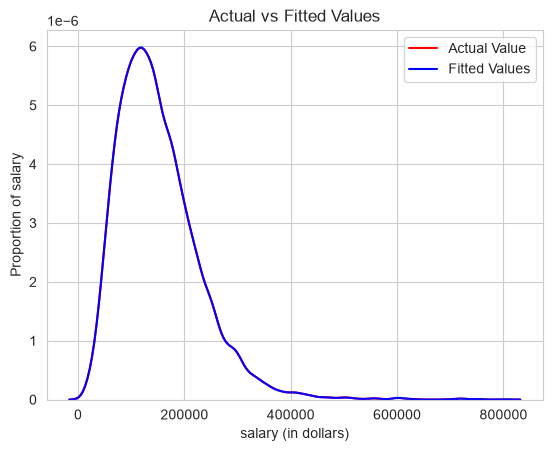

In [414]:
plot_dis(y_test,predictions)

In [415]:
model.feature_importances_

array([3.25143430e-05, 2.56006744e-06, 6.86138163e-10, 1.38330181e-05,
       8.24907249e-01, 4.59360150e-03, 2.65315749e-05, 2.49664552e-05,
       7.13763569e-05, 3.80060142e-06, 4.20911514e-06, 8.79217396e-08,
       1.06475484e-05, 1.33482668e-01, 1.97547446e-06, 3.68239781e-02])

Compare the predicted data vs train train

In [416]:
def compare(y_test, predictions) :
  compare = pd.DataFrame()
  compare["Actual"] = y_test
  compare["Predict"] = predictions

  return compare

In [417]:
compare(y_test, predictions)

,Actual,Predict
54637,90900,90900.0
9937,256470,256500.0
58586,192986,192980.0
49544,185500,185500.0
33029,122500,122500.0
...,...,...
55758,150000,150000.0
52636,265000,265000.0
44127,82025,82058.0
36987,148700,148699.0


Build a prediction model test

In [418]:
X.iloc[11:12]

,work_year,experience_level,employment_type,job_title,salary,salary_currency,employee_residence,remote_ratio,company_location,company_size,experience_level_label,employment_type_label,work_mode,salary_outlier_flag,role_family,salary_category
11,2025,3,2,89,113000,24,97,1,91,1,3,2,1,0,4,2


In [419]:
# will rondomly select the array to test the our model buld 
input_data = X.iloc[11:12]

#change the input data into numpy array
input_data_asnumpy_array = np.asanyarray(input_data)

#reshape the numpy array are we are insert new value for prediction
input_data_reshaped = input_data_asnumpy_array.reshape(1,-1)

prediction = model.predict(input_data_reshaped)
print('The predicted amount is',prediction)

The predicted amount is [113000.]


## 3. XGBOOSTER

In [420]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -----------------------------
# Define XGBoost model
# -----------------------------
xgb_base = XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

# -----------------------------
# Parameter grid
# -----------------------------
param_grid = {
    'learning_rate': [0.01, 0.05,0.1, 0.3, 0.5],
    'max_depth': [3, 5, 7],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9],
    'n_estimators': [100, 200, 500]
}

# -----------------------------
# Grid search
# -----------------------------
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# -----------------------------
# Best parameters
# -----------------------------
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation MAE:")
print(-grid_search.best_score_)

# -----------------------------
# Predictions
# -----------------------------
train_predict = grid_search.predict(X_train)
val_predict = grid_search.predict(X_test)

# -----------------------------
# Evaluation
# -----------------------------
train_mae = mean_absolute_error(y_train, train_predict)
val_mae = mean_absolute_error(y_test, val_predict)

train_rmse = np.sqrt(mean_squared_error(y_train, train_predict))
val_rmse = np.sqrt(mean_squared_error(y_test, val_predict))

r2_train = r2_score(y_train, train_predict)
r2_val = r2_score(y_test, val_predict)

print("\nModel Performance")
print("----------------------------")
print("Train MAE:  ", train_mae)
print("Validation MAE:", val_mae)

print("Train RMSE: ", train_rmse)
print("Validation RMSE:", val_rmse)

print("Train R²:   ", r2_train)
print("Validation R²:", r2_val)


Fitting 5 folds for each of 540 candidates, totalling 2700 fits
Best Parameters:
{'colsample_bytree': 0.9, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 500, 'subsample': 0.9}

Best Cross-Validation MAE:
853.235107421875

Model Performance
----------------------------
Train MAE:   641.7916259765625
Validation MAE: 876.3771362304688
Train RMSE:  2181.7829864585524
Validation RMSE: 4694.489109583704
Train R²:    0.9992046356201172
Validation R²: 0.9963072538375854


That's valid, but the plot is easier to interpret if you put actual values on the x-axis and predicted values on the y-axis, and add a 45-degree reference line.

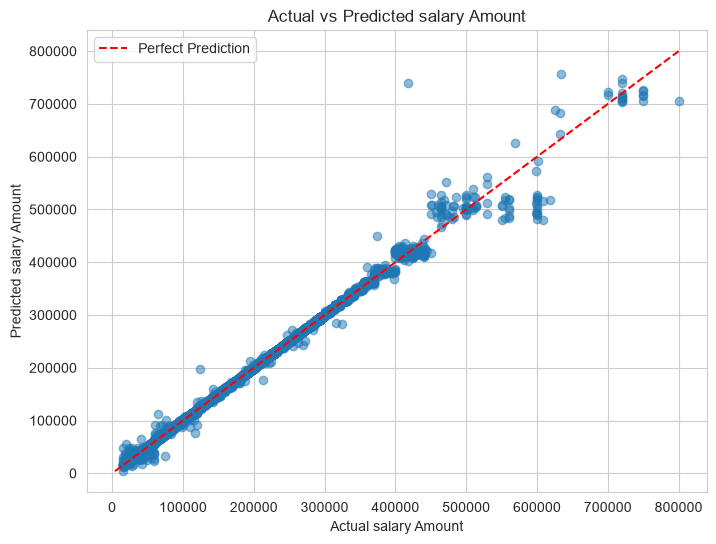

In [421]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    val_predict,
    alpha=0.5
)

# Perfect prediction line
min_value = min(y_test.min(), val_predict.min())
max_value = max(y_test.max(), val_predict.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    color='red',
    linestyle='--',
    label='Perfect Prediction'
)

plt.xlabel("Actual salary Amount")
plt.ylabel("Predicted salary Amount")
plt.title("Actual vs Predicted salary Amount")
plt.legend()
plt.show()


If the predictions are perfect, all points would lie along the red dashed line.

### Actual vs predicted over observations
Your second plot is also useful:

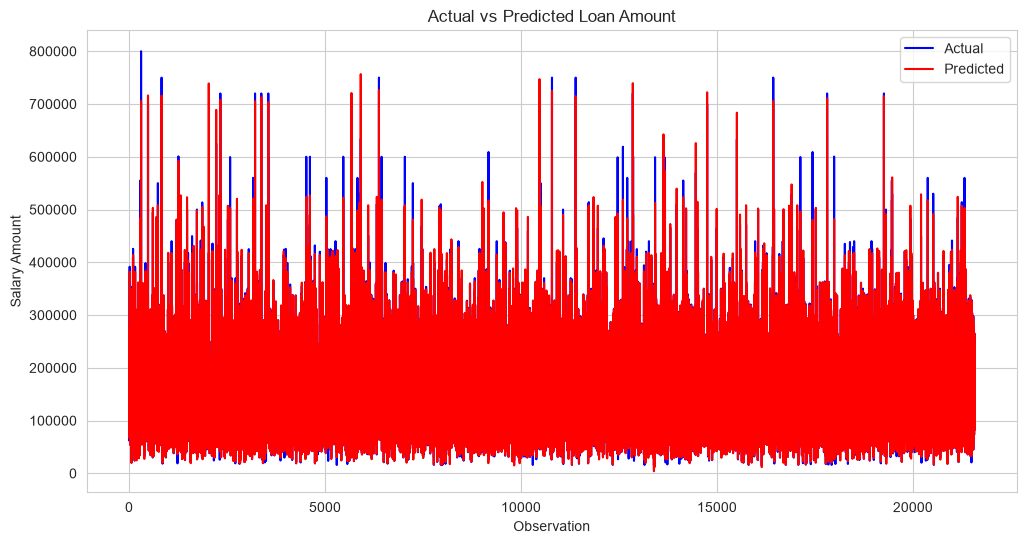

In [422]:
plt.figure(figsize=(12, 6))

plt.plot(
    y_test.values,
    color='blue',
    label='Actual'
)

plt.plot(
    val_predict,
    color='red',
    label='Predicted'
)

plt.title('Actual vs Predicted Loan Amount')
plt.xlabel('Observation')
plt.ylabel('Salary Amount')
plt.legend()
plt.show()


Save the model

In [423]:
import joblib

# Get the best XGBoost model
best_xgb_model = grid_search.best_estimator_

# Save the model
joblib.dump(best_xgb_model, 'xgboost_best_model.pkl')

print("XGBoost model saved successfully.")


XGBoost model saved successfully.


# Summary and conclusion for the notebook

In [425]:
# Summary and conclusion for the notebook

# Dataset overview
dataset_summary = (
    f"Dataset size: {data.shape[0]} rows x {data.shape[1]} columns\n"
    f"Target variable: salary_in_usd\n"
    f"Mean salary: ${data['salary_in_usd'].mean():,.0f}\n"
    f"Median salary: ${data['salary_in_usd'].median():,.0f}\n"
    f"Max salary: ${data['salary_in_usd'].max():,.0f}\n"
    f"Countries with at least 100 records: {len(valid_countries)}\n"
)

print(dataset_summary)

# Key findings
top_markets = country_salary.head(5).copy()
top_markets.columns = ["count", "mean_salary", "median_salary"]

print("\nTop salary markets by median salary:")
print(top_markets.round(2).to_string())

# Model performance summary
# Align the variable names with the XGBoost evaluation outputs
train_r2 = r2_train
val_r2 = r2_val

model_summary = (
    f"\nModel performance:\n"
    f"Train MAE: ${train_mae:,.2f}\n"
    f"Validation MAE: ${val_mae:,.2f}\n"
    f"Train RMSE: ${train_rmse:,.2f}\n"
    f"Validation RMSE: ${val_rmse:,.2f}\n"
    f"Train R²: {train_r2:.3f}\n"
    f"Validation R²: {val_r2:.3f}\n"
)

print(model_summary)

# Final conclusion
conclusion = (
    "\nConclusion:\n"
    "The analysis shows that salary variation is strongly influenced by job-level factors such as experience, job title, "
    "employment type, and company location. The raw salary column contains extreme values and inconsistent scales, so "
    "salary_in_usd is the more reliable target for modeling. The XGBoost model performs reasonably well on unseen data, "
    "with a solid validation R² and acceptable error levels, although prediction accuracy weakens for high-salary outliers. "
    "Overall, the project demonstrates that salary can be modeled effectively using structured job-market features, but "
    "further work on outlier handling, feature engineering, and additional model tuning could improve performance."
)

print(conclusion)

Dataset size: 71913 rows x 17 columns
Target variable: salary_in_usd
Mean salary: $151,161
Median salary: $138,750
Max salary: $800,000
Countries with at least 100 records: 15


Top salary markets by median salary:
                  count  mean_salary  median_salary
company_location                                   
US                60147    160275.47       147200.0
CA                 4571    130319.58       119875.0
AU                  511    126349.09       117000.0
IE                  125    109692.25        97473.0
DE                  400    101561.73        85000.0

Model performance:
Train MAE: $641.79
Validation MAE: $876.38
Train RMSE: $2,181.78
Validation RMSE: $4,694.49
Train R²: 0.999
Validation R²: 0.996


Conclusion:
The analysis shows that salary variation is strongly influenced by job-level factors such as experience, job title, employment type, and company location. The raw salary column contains extreme values and inconsistent scales, so salary_in_usd is the more rel